In [1]:
import orc
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
class TwoMassSpringSystem:
    """
    Two-mass spring-damper system connected to a wall.
    
    Wall ---[k1, c1]--- m1 ---[k2, c2]--- m2
    
    State vector: [x1, x2, v1, v2] (positions and velocities)
    Input: Force applied to mass 1
    Output: Positions of both masses [x1, x2]
    """
    
    def __init__(self, m1=1.0, m2=1.0, k1=1.0, k2=1.0, c1=0.0, c2=0.0, dt=0.01):
        self.m1 = m1
        self.m2 = m2
        self.k1 = k1
        self.k2 = k2
        self.c1 = c1
        self.c2 = c2
        self.dt = dt
        
        # Continuous-time state matrix with damping
        # State: [x1, x2, v1, v2]
        A_cont = jnp.array([
            [0, 0, 1, 0],
            [0, 0, 0, 1],
            [-(k1 + k2) / m1, k2 / m1, -(c1 + c2) / m1, c2 / m1],
            [k2 / m2, -k2 / m2, c2 / m2, -c2 / m2]
        ])
        
        # Continuous-time input matrix (force on m1)
        B_cont = jnp.array([[0], [0], [1 / m1], [0]])
        
        # Discretize using Euler method
        self.A = jnp.eye(4) + dt * A_cont
        self.B = dt * B_cont
        
        # Output matrix: observe positions [x1, x2]
        self.C = jnp.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])
        self.D = jnp.zeros((2, 1))
        
        self.state_dim = 4
        self.output_dim = 2
    
    def step(self, x, u):
        """Single timestep."""
        u = jnp.atleast_1d(u).reshape(-1, 1)
        x_next = self.A @ x + self.B @ u
        y = self.C @ x_next + self.D @ u
        return x_next, y.flatten()
    
    def simulate(self, u_sequence, x0=None):
        """Simulate over input sequence."""
        T = len(u_sequence)
        x = x0 if x0 is not None else jnp.zeros((self.state_dim, 1))
        
        states = []
        outputs = []
        
        for t in range(T):
            x, y = self.step(x, u_sequence[t])
            states.append(x.flatten())
            outputs.append(y)
        
        return jnp.stack(states), jnp.stack(outputs)

(1000, 1)


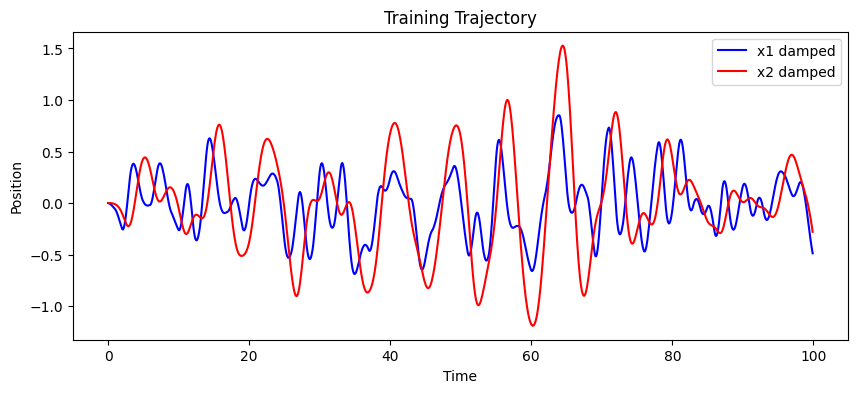

: 

In [ ]:
system_damped = TwoMassSpringSystem(m1=1.0, m2=1.0, k1=2.0, k2=1.0, c1=0.4, c2=0.4, dt=0.1)

# Impulse input
T = 1000
t = jnp.arange(T) * 0.1
u = jax.random.uniform(jax.random.key(0), shape=(100,), minval=-1, maxval=1)
u = jnp.repeat(u, 10).reshape(-1, 1)
print(u.shape)

states_damped, outputs_damped = system_damped.simulate(u)

plt.figure(figsize=(10, 4))
plt.plot(t, outputs_damped[:, 0], 'b-', label='x1 damped')
plt.plot(t, outputs_damped[:, 1], 'r-', label='x2 damped')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.title('Training Trajectory')
plt.show()

In [4]:
control_model = orc.control.ESNController(data_dim=2, control_dim=1, res_dim=1000)
control_model, R = orc.control.train_ESNController(control_model, outputs_damped[:-1], u[1:])

In [5]:
ref_traj = jnp.zeros((500, 2))
r0 = R[-1]
state, output = states_damped[-1:], outputs_damped[-1:]
state_list = []
control_list = []

for i in range(250):
    comp_control = control_model.compute_control(
        jnp.zeros((20, 1)), res_state=r0, ref_traj=ref_traj[i:i+20]
    )

    r0 = control_model.force(output, comp_control[0:1,0:1], r0)[0]

    state, output = system_damped.simulate(comp_control[0:1,0:1], state.reshape(4,-1))
    state_list.append(state)
    control_list.append(comp_control[0,0])


state_list = jnp.array(state_list)

control_list = jnp.array(control_list)

In [6]:
uncontrolled_states, uncontrolled_outputs = system_damped.simulate(jnp.zeros((250,1)), states_damped[-1:].reshape(4,-1))

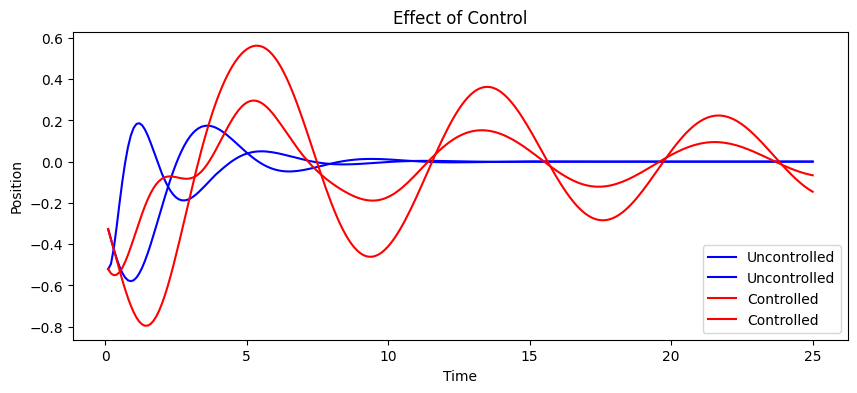

In [7]:
t = jnp.arange(1, 251) * 0.1
plt.figure(figsize=(10, 4))
plt.plot(t, state_list[:, 0, [0,1]], 'b-', label='Uncontrolled')
plt.plot(t, uncontrolled_outputs, 'r-', label='Controlled')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.title('Effect of Control')
plt.show()